In [131]:
import os
import datetime
import numpy as np
import pandas as pd
from absl import app
from tqdm.notebook import tqdm
import compress_pickle
from absl import flags
from absl import logging
from typing import Sequence
import matplotlib.pyplot as plt
from scipy.stats import bootstrap
import pathos.multiprocessing as mp
import machine_contest_metrics as mcm
import parameterized_sample_lib as psample
import cat_machine_contest_metrics as cmcm

In [132]:
params_list = [] 
all_params_list = [] 
ks = [x for x in range(1,11)] 
ks.extend([x for x in range(20,1001, 20)])

def get_n_k_for_num_ratings(all_values, num_ratings=5000): 
    values=[] 
    for x in all_values:
        if x==0:
            x=1 
        n = int(np.floor(num_ratings/x)) 
        # if n > 30:
        values.append((n, int(x))) 
    return values
# vals = get_n_k_for_num_ratings(ks) 
# [x[1] for x in vals], [x[0] for x in vals]
ratings_list = [] 
# nk_list = [5000]
nk_list = [2500, 5000, 10000, 25000, 50000]
# nk_list = [1000, 2500, 5000, 10000, 25000, 50000]
# for r in range(1000, 5001, 1000):
# for r in range(5000, 5001, 500): 
for r in nk_list:
    params = get_n_k_for_num_ratings(ks, r) 
    params_list.append(params)
    all_params_list.extend(params) 
    ratings_list.extend([(r-x[0]*x[1]) for x in params])
    print(params)

[(2500, 1), (1250, 2), (833, 3), (625, 4), (500, 5), (416, 6), (357, 7), (312, 8), (277, 9), (250, 10), (125, 20), (62, 40), (41, 60), (31, 80), (25, 100), (20, 120), (17, 140), (15, 160), (13, 180), (12, 200), (11, 220), (10, 240), (9, 260), (8, 280), (8, 300), (7, 320), (7, 340), (6, 360), (6, 380), (6, 400), (5, 420), (5, 440), (5, 460), (5, 480), (5, 500), (4, 520), (4, 540), (4, 560), (4, 580), (4, 600), (4, 620), (3, 640), (3, 660), (3, 680), (3, 700), (3, 720), (3, 740), (3, 760), (3, 780), (3, 800), (3, 820), (2, 840), (2, 860), (2, 880), (2, 900), (2, 920), (2, 940), (2, 960), (2, 980), (2, 1000)]
[(5000, 1), (2500, 2), (1666, 3), (1250, 4), (1000, 5), (833, 6), (714, 7), (625, 8), (555, 9), (500, 10), (250, 20), (125, 40), (83, 60), (62, 80), (50, 100), (41, 120), (35, 140), (31, 160), (27, 180), (25, 200), (22, 220), (20, 240), (19, 260), (17, 280), (16, 300), (15, 320), (14, 340), (13, 360), (13, 380), (12, 400), (11, 420), (11, 440), (10, 460), (10, 480), (10, 500), (9, 52

In [133]:
def gather_data(_N_ITEMS, _K_RESPONSES, distortion_values, exp_dir, metrics_list, _M_CATEGORIES): 
    final_table = pd.DataFrame() 
    for distortion in distortion_values:
        file_path = f'{exp_dir}results_N={_N_ITEMS}_K={_K_RESPONSES}_cat_responses_simulated_distr_dist={distortion}_gen_N={_N_ITEMS}_K={_K_RESPONSES}_M={_M_CATEGORIES}_num_samples=1000.pkl.csv'
        experiment_results = pd.read_csv(file_path)
        
        intermediate_table = pd.DataFrame() 
        intermediate_table['$\\Delta$'] = (experiment_results['M2 GT Alt'] - experiment_results['M1 GT Alt']).abs() 
        intermediate_table['p-value'] = experiment_results['GT_Pvalue'] 
        # intermediate_table['Metric'] = ['$\\Gamma_{\\rm Accuracy}$', '$\\Gamma_{\\rm F1-score}$']  
        intermediate_table['Metric'] = metrics_list 
        # intermediate_table['Metric'] = ['Accuracy'] 
        intermediate_table[f'$\\epsilon$'] = distortion 
        final_table = pd.concat([final_table, intermediate_table]) 
 
    final_table = final_table.melt(["Metric", "$\\epsilon$"]).sort_values(by=["Metric","variable"]).pivot(index = "$\\epsilon$", columns=["Metric","variable"]) 
    # final_table = final_table.reset_index(drop=True) 
    final_table = final_table.reset_index() 
    final_table.columns = pd.MultiIndex.from_tuples([(j,k) for i,j,k in final_table.columns]) 
    final_table.columns = ['_'.join(col) for col in final_table.columns] 
    final_table["N"] = pd.Series([_N_ITEMS]*len(distortion_values)) 
    final_table["K"] = pd.Series([_K_RESPONSES]*len(distortion_values)) 
    # final_table["NxK"] = final_table["N"]*final_table["K"] 
 
    return final_table

In [134]:
# dataset_info = {"exp_dir": "../../../../data/ptest_arr_dices/", "dataset": "DICES", "num_categories": "3",}
dataset_info = {"exp_dir": "../../../../data/ptest_arr_d3code/", "dataset": "D3code", "num_categories": "2",}
# dataset_info = {"exp_dir": "../../../../data/ptest_arr_jobsQ1/", "dataset": "JobsQ1", "num_categories": "5",}
# dataset_info = {"exp_dir": "../../../../data/ptest_arr_jobsQ3/", "dataset": "JobsQ3", "num_categories": "12",}
# dataset_info = {"exp_dir": "../../../../data/ptest_arr_toxicity/", "dataset": "Toxicity", "num_categories": "2",}


_M_CATEGORIES = dataset_info['num_categories']
exp_dir = dataset_info['exp_dir']
dataset = dataset_info['dataset']

distortion=0.2
n_items = 1000
k_responses = 10

metrics_list = ['Accuracy', 'MAE', 'Wins', 'KL-Div']


# response_sets = psample.read_samples_from_file(f"{exp_dir}cat_responses_simulated_distr_dist={distortion}_gen_N=5000_K=100_M=12_num_samples=1000.pkl", True)
response_sets = psample.read_samples_from_file(f"{exp_dir}cat_responses_simulated_distr_dist={distortion}_gen_N={n_items}_K={k_responses}_M={_M_CATEGORIES}_num_samples=1000.pkl.lz4", True)

response_sets.truncate(n_items, k_responses)

In [135]:
final_table = gather_data(n_items, k_responses, [distortion], exp_dir, metrics_list, _M_CATEGORIES)
final_table

,_,Accuracy_$\Delta$,Accuracy_p-value,KL-Div_$\Delta$,KL-Div_p-value,MAE_$\Delta$,MAE_p-value,Wins_$\Delta$,Wins_p-value,N,K
0,0.2,0.031657,0.052839,0.079207,0.194024,0.017693,0.007484,70.611612,0.031425,1000,10


In [136]:
def calculate_metric_scores(idx, response_sets, metric):
    null_score=(0.0,0.0)
    alt_score=(0.0,0.0)

    null_simulated_data_gold = response_sets.null_data_list[idx].gold
    null_simulated_data_preds1 = response_sets.null_data_list[idx].preds1
    null_simulated_data_preds2 = response_sets.null_data_list[idx].preds2

    alt_simulated_data_gold = response_sets.alt_data_list[idx].gold
    alt_simulated_data_preds1 = response_sets.alt_data_list[idx].preds1
    alt_simulated_data_preds2 = response_sets.alt_data_list[idx].preds2

    if metric=="Accuracy":
        null_score = cmcm.cat_accuracy(null_simulated_data_gold, null_simulated_data_preds1, null_simulated_data_preds2)
        alt_score = cmcm.cat_accuracy(alt_simulated_data_gold, alt_simulated_data_preds1, alt_simulated_data_preds2)
    if metric=="F1-score":
        null_score = cmcm.cat_f1_score(null_simulated_data_gold, null_simulated_data_preds1, null_simulated_data_preds2)
        alt_score = cmcm.cat_f1_score(alt_simulated_data_gold, alt_simulated_data_preds1, alt_simulated_data_preds2)
    if metric=="MAE":
        null_score = cmcm.cat_mean_absolute_error(null_simulated_data_gold, null_simulated_data_preds1, null_simulated_data_preds2)
        alt_score = cmcm.cat_mean_absolute_error(alt_simulated_data_gold, alt_simulated_data_preds1, alt_simulated_data_preds2)
    if metric=="Wins":
        null_score = cmcm.cat_wins_mae(null_simulated_data_gold, null_simulated_data_preds1, null_simulated_data_preds2)
        alt_score = cmcm.cat_wins_mae(alt_simulated_data_gold, alt_simulated_data_preds1, alt_simulated_data_preds2)
    if metric=="KL-Div":
        null_score = cmcm.cat_kl_div(null_simulated_data_gold, null_simulated_data_preds1, null_simulated_data_preds2)
        alt_score = cmcm.cat_kl_div(alt_simulated_data_gold, alt_simulated_data_preds1, alt_simulated_data_preds2)
    
    return null_score, alt_score


def get_parallel_metric_scores(response_sets, metric):

    null_scores = []
    alt_scores = []
    scores_trials = []

    args = [(i, response_sets, metric) for i in range(1000)]
    with mp.Pool(mp.cpu_count()) as pool:
        scores_trials = pool.starmap(calculate_metric_scores, args)

    if scores_trials:
        scores_list = list(map(list, zip(*scores_trials)))
        null_scores, alt_scores = scores_list[0], scores_list[1]

    return  null_scores, alt_scores


def get_metric_scores(response_sets, metric):

    null_scores = []
    alt_scores = []
    for i in range(1000):
        null_score=(0.0,0.0)
        alt_score=(0.0,0.0)

        null_simulated_data_gold = response_sets.null_data_list[i].gold
        null_simulated_data_preds1 = response_sets.null_data_list[i].preds1
        null_simulated_data_preds2 = response_sets.null_data_list[i].preds2

        alt_simulated_data_gold = response_sets.alt_data_list[i].gold
        alt_simulated_data_preds1 = response_sets.alt_data_list[i].preds1
        alt_simulated_data_preds2 = response_sets.alt_data_list[i].preds2

        if metric=="Accuracy":
            null_score = cmcm.cat_accuracy(null_simulated_data_gold, null_simulated_data_preds1, null_simulated_data_preds2)
            alt_score = cmcm.cat_accuracy(alt_simulated_data_gold, alt_simulated_data_preds1, alt_simulated_data_preds2)
        if metric=="F1-score":
            null_score = cmcm.cat_f1_score(null_simulated_data_gold, null_simulated_data_preds1, null_simulated_data_preds2)
            alt_score = cmcm.cat_f1_score(alt_simulated_data_gold, alt_simulated_data_preds1, alt_simulated_data_preds2)
        if metric=="MAE":
            null_score = cmcm.cat_mean_absolute_error(null_simulated_data_gold, null_simulated_data_preds1, null_simulated_data_preds2)
            alt_score = cmcm.cat_mean_absolute_error(alt_simulated_data_gold, alt_simulated_data_preds1, alt_simulated_data_preds2)
        if metric=="Wins":
            null_score = cmcm.cat_wins_mae(null_simulated_data_gold, null_simulated_data_preds1, null_simulated_data_preds2)
            alt_score = cmcm.cat_wins_mae(alt_simulated_data_gold, alt_simulated_data_preds1, alt_simulated_data_preds2)
        if metric=="KL-Div":
            null_score = cmcm.cat_kl_div(null_simulated_data_gold, null_simulated_data_preds1, null_simulated_data_preds2)
            alt_score = cmcm.cat_kl_div(alt_simulated_data_gold, alt_simulated_data_preds1, alt_simulated_data_preds2)
        
        null_scores.append(null_score)
        alt_scores.append(alt_score)
    
    return  null_scores, alt_scores


def process_scores(null_scores, alt_scores):
    null_scores_m1 = [x[0] for x in null_scores]
    null_scores_m2 = [x[1] for x in null_scores]
    alt_scores_m1 = [x[0] for x in alt_scores]
    alt_scores_m2 = [x[1] for x in alt_scores]

    gamma_null_scores = np.array(null_scores_m1) - np.array(null_scores_m2)
    gamma_alt_scores = np.array(alt_scores_m1) - np.array(alt_scores_m2)
    
    return gamma_null_scores, gamma_alt_scores


In [137]:
metric = "Accuracy"
# metric = "F1-score"
# metric = "MAE"
# metric = "Wins"
# metric = "KL-Div"

null_scores, alt_scores = get_metric_scores(response_sets, metric)

null_scores_m1 = [x[0] for x in null_scores]
null_scores_m2 = [x[1] for x in null_scores]
alt_scores_m1 = [x[0] for x in alt_scores]
alt_scores_m2 = [x[1] for x in alt_scores]

null_mean_m1 = np.mean(null_scores_m1)
null_var_m1 = np.var(null_scores_m1)
null_mean_m2 = np.mean(null_scores_m2)
null_var_m2 = np.var(null_scores_m2)

alt_mean_m1 = np.mean(alt_scores_m1)
alt_var_m1 = np.var(alt_scores_m1)
alt_mean_m2 = np.mean(alt_scores_m2)
alt_var_m2 = np.var(alt_scores_m2)

gamma_null_scores = np.array(null_scores_m1) - np.array(null_scores_m2)
gamma_alt_scores = np.array(alt_scores_m1) - np.array(alt_scores_m2)

In [138]:
null_mean_m1, null_mean_m2, alt_mean_m1, alt_mean_m2

(0.8210660000000001, 0.820845, 0.831843, 0.800214)

In [139]:
def calculate_ci(scores, confidence_level=0.95):
    alpha = 1-confidence_level
    g_hat = scores[0]
    lower = np.percentile(scores, 100*alpha/2)
    upper = np.percentile(scores, 100*(1-alpha/2))
    return 2*g_hat-upper, 2*g_hat-lower

def calculate_per_ci(scores, confidence_level=0.95):
    alpha = 1-confidence_level
    lower = np.percentile(scores, 100*alpha/2)
    upper = np.percentile(scores, 100*(1-alpha/2))
    return lower, upper

print(calculate_per_ci(gamma_null_scores, confidence_level=0.95), calculate_ci(gamma_null_scores, confidence_level=0.95), gamma_null_scores[0])
print(calculate_per_ci(gamma_alt_scores, confidence_level=0.95), calculate_ci(gamma_alt_scores, confidence_level=0.95), gamma_alt_scores[0])

(-0.026999999999999913, 0.027024999999999997) (-0.027024999999999997, 0.026999999999999913) 0.0
(0.006000000000000005, 0.05999999999999994) (-0.051999999999999935, 0.0020000000000000018) 0.0040000000000000036


In [140]:
null_ci, alt_ci = calculate_ci(gamma_null_scores, confidence_level=0.95), calculate_ci(gamma_alt_scores, confidence_level=0.95)

In [141]:
null_data = (gamma_null_scores,)
alt_data = (gamma_alt_scores,)
bootstrap(null_data, np.mean, confidence_level=0.95), bootstrap(alt_data, np.mean, confidence_level=0.95)

(BootstrapResult(confidence_interval=ConfidenceInterval(low=-0.0006190000000000012, high=0.0010299999999999966), bootstrap_distribution=array([ 5.53e-04, -1.38e-04,  4.01e-04, ...,  8.06e-04,  4.87e-04,
        -1.90e-05]), standard_error=0.0004206127126486677),
 BootstrapResult(confidence_interval=ConfidenceInterval(low=0.030772763845192765, high=0.032476999999999936), bootstrap_distribution=array([0.031439, 0.03094 , 0.031995, ..., 0.031381, 0.03151 , 0.031627]), standard_error=0.0004355179018165196))

/tmp/ipykernel_624061/548028379.py:14: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  plt.text(0.2, plt.ylim()[1]*0.85, f'p-val: {float(final_table[f"{metric}_p-value"]):.6f}', fontsize=9, color='blue')


Text(0.5, 1.0, 'D3code - Distribution of Accuracy ($\\epsilon$=0.2)')

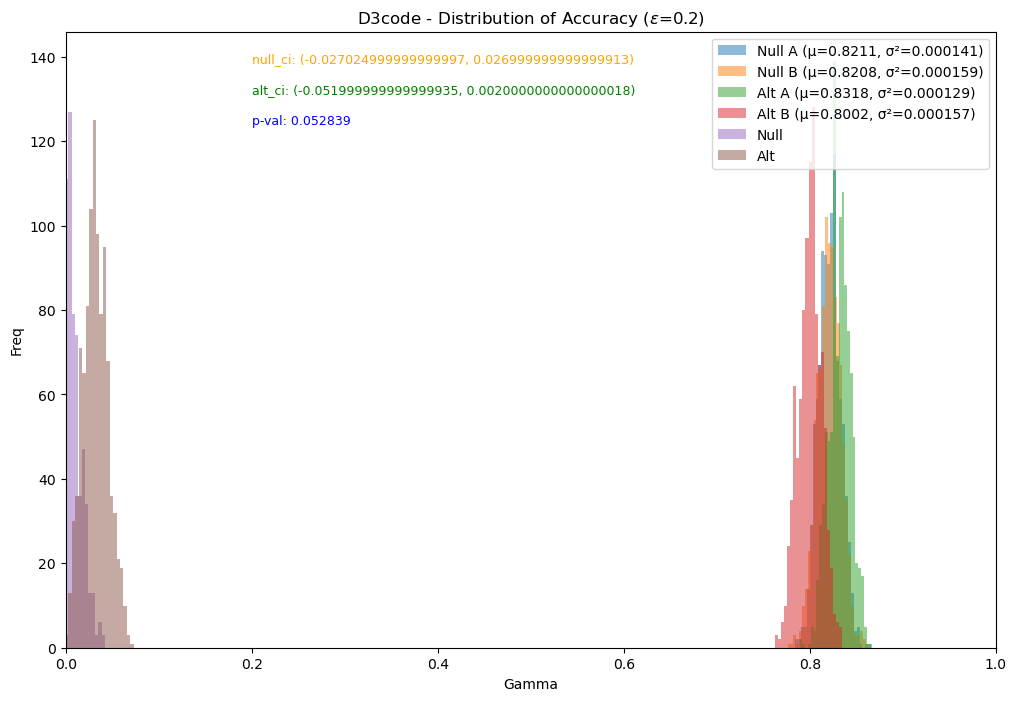

In [142]:
plt.figure(figsize=(12, 8))
plt.hist(null_scores_m1, bins='auto', alpha=0.5, label=f'Null A (μ={null_mean_m1:.4f}, σ²={null_var_m1:.6f})')
plt.hist(null_scores_m2, bins='auto', alpha=0.5, label=f'Null B (μ={null_mean_m2:.4f}, σ²={null_var_m2:.6f})')
plt.hist(alt_scores_m1, bins='auto', alpha=0.5, label=f'Alt A (μ={alt_mean_m1:.4f}, σ²={alt_var_m1:.6f})')
plt.hist(alt_scores_m2, bins='auto', alpha=0.5, label=f'Alt B (μ={alt_mean_m2:.4f}, σ²={alt_var_m2:.6f})')
plt.hist(gamma_null_scores, bins='auto', alpha=0.5, label='Null')
plt.hist(gamma_alt_scores, bins='auto', alpha=0.5, label='Alt')

# plt.text(0.02, plt.ylim()[1]*0.9, f'M1: μ={mean_m1:.2f}, σ²={var_m1:.6f}', fontsize=9, color='blue')
# plt.text(0.02, plt.ylim()[1]*0.8, f'M2: μ={mean_m2:.2f}, σ²={var_m2:.6f}', fontsize=9, color='orange')
# plt.text((mean_m1+mean_m2)/2+0.05, plt.ylim()[1]*0.8, f'p-val: {float(final_table[f"{metric}_p-value"]):.6f}', fontsize=9, color='green')
plt.text(0.2, plt.ylim()[1]*0.95, f'null_ci: {null_ci}', fontsize=9, color='orange')
plt.text(0.2, plt.ylim()[1]*0.9, f'alt_ci: {alt_ci}', fontsize=9, color='green')
plt.text(0.2, plt.ylim()[1]*0.85, f'p-val: {float(final_table[f"{metric}_p-value"]):.6f}', fontsize=9, color='blue')

plt.xlabel('Gamma')
plt.ylabel('Freq')
plt.xlim((0,1))
plt.legend(loc='upper right')
plt.title(f"{dataset} - Distribution of {metric} ($\\epsilon$={distortion})")

# plt.tight_layout()
# plt.savefig(f"output/{dataset}_dist_n={n_items}_k={k_responses}_{metric}_e_{distortion}.png")
# plt.show()
# plt.close()

In [143]:
def get_bootstrap_power(gamma_null_scores, gamma_alt_scores, significance=0.05, num_samples=10000, paired=True):
    power = 0.0

    p_values = []
    for _ in range(num_samples):
        if paired:
            len_data = len(gamma_alt_scores)
            indices = np.random.choice(range(len_data), size=len_data, replace=True)
            bootstrap_null_scores, bootstrap_alt_scores = gamma_null_scores[indices], gamma_alt_scores[indices]
        else:
            bootstrap_null_scores = np.random.choice(gamma_null_scores, size=len(gamma_null_scores), replace=True)
            bootstrap_alt_scores = np.random.choice(gamma_alt_scores, size=len(gamma_alt_scores), replace=True)

        p_value = mcm.calculate_p_value(bootstrap_null_scores, bootstrap_alt_scores)
        p_values.append(p_value)

    power = np.mean(np.array(p_values) < significance, axis=-1)

    return power, p_values

In [145]:
# print(gamma_null_scores[:10], gamma_alt_scores[:10])
get_bootstrap_power(gamma_null_scores, gamma_alt_scores)[0], get_bootstrap_power(gamma_null_scores, gamma_alt_scores, paired=False)[0]

(0.2497, 0.254)

In [14]:
def get_bootstrap_result(gamma_null_scores, gamma_alt_scores, confidence_level=0.95, method='BCa'):
    
    null_data = (gamma_null_scores,)
    alt_data = (gamma_alt_scores,)
    null_res = bootstrap(null_data, np.mean, confidence_level=confidence_level, method=method)
    alt_res = bootstrap(alt_data, np.mean, confidence_level=confidence_level, method=method)

    return null_res, alt_res

# gamma_null_scores, gamma_alt_scores = process_scores(null_scores, alt_scores)
# null_res, alt_res = get_bootstrap_result(gamma_null_scores, gamma_alt_scores)
# alt_ci = alt_res.confidence_interval

In [14]:
def plot_ci(alt_ci_nk_list, nk_list, x_list, metric, distortion, dataset, col, base_path):

    plt.figure(figsize=(12, 8))

    title_fontsize = 30
    label_fontsize = 30
    tick_fontsize = 30
    legend_fontsize = 30


    for idx, nk in enumerate(nk_list):
        if len(alt_ci_nk_list) > idx:
            ci_lower = [x[0].low for x in alt_ci_nk_list[idx]]
            ci_upper = [x[0].high for x in alt_ci_nk_list[idx]]
            stat_means = [x[1] for x in alt_ci_nk_list[idx]]
            plt.plot(x_list[idx], stat_means, marker='o', label=f'NxK={nk}')
            # plt.fill_between([x[1] for x in params_list[0][:35]], ci_lower, ci_upper, color='blue', alpha=0.2, label=f'{int(confidence_level*100)}% Confidence Interval')
            plt.fill_between(x_list[idx], ci_lower, ci_upper, alpha=0.2)
            # break

    plt.xlabel(col, fontsize=label_fontsize)
    plt.ylabel('CI', fontsize=label_fontsize)
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    plt.title(f"CI - {dataset} ({metric}, $\\epsilon$={distortion})", fontsize=title_fontsize)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.35), ncols=3, fontsize=legend_fontsize)
    plt.savefig(f"{base_path}/{dataset}_CI_{metric}_{col}_500_e_{distortion}.pdf", bbox_inches='tight')
    plt.close()

In [15]:
def plot_ci_width(alt_ci_nk_list, nk_list, x_list, metric, distortion, dataset, col, base_path):

    plt.figure(figsize=(12, 8))

    title_fontsize = 30
    label_fontsize = 30
    tick_fontsize = 30
    legend_fontsize = 30

    for idx, nk in enumerate(nk_list):
        if len(alt_ci_nk_list) > idx:
            ci_lower = [x[0].low for x in alt_ci_nk_list[idx]]
            ci_upper = [x[0].high for x in alt_ci_nk_list[idx]]
            ci_width = np.array(ci_upper) - np.array(ci_lower)
            plt.plot(x_list[idx], ci_width, marker='o', label=f'NxK={nk}')
            # break

    plt.xlabel(col, fontsize=label_fontsize)
    plt.ylabel('CI', fontsize=label_fontsize)
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    plt.title(f"CI - {dataset} ({metric}, $\\epsilon$={distortion})", fontsize=title_fontsize)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.35), ncols=3, fontsize=legend_fontsize)
    plt.savefig(f"{base_path}/{dataset}_CI_width_{metric}_{col}_500_e_{distortion}.pdf", bbox_inches='tight')
    plt.close()

In [16]:
def write_ci_to_file(ci, output_filename):
    write_start_time = datetime.datetime.now()
    
    with open(output_filename, "wb") as f:
        compress_pickle.dump(ci, f)
        
    elapsed_time = datetime.datetime.now() - write_start_time
    logging.info("File writing time=%f", elapsed_time.total_seconds())

In [ ]:
_M_CATEGORIES = dataset_info['num_categories']
exp_dir = dataset_info['exp_dir']
dataset = dataset_info['dataset']


# distortion=0.1
distortion_values = [0.1, 0.2, 0.3, 0.4]

confidence_level = 0.95
col='K'

metrics_list = ['Accuracy', 'MAE', 'Wins', 'KL-Div']
# metric = metrics_list[1]

# base_path = "output/ci_plots"
base_path = f"output/ci_plots/{dataset}"
if not os.path.exists(base_path):
    os.mkdir(base_path)

ci_path = f"{exp_dir}ci"
if not os.path.exists(ci_path):
    os.mkdir(ci_path)


start_time = datetime.datetime.now()

for distortion in tqdm(distortion_values, desc="Plotting CIs"):
    x_list = []
    alt_ci_nk_dict = {}
    for i, nks in tqdm(enumerate(params_list), desc="Calculating CIs", leave=False):
        xs = []
        alt_ci_dict = {}
        for n_items, k_responses in tqdm(nks[:35], desc="Processing", leave=False):

            response_sets = psample.read_samples_from_file(f"{exp_dir}cat_responses_simulated_distr_dist={distortion}_gen_N={n_items}_K={k_responses}_M={_M_CATEGORIES}_num_samples=1000.pkl.lz4", True)
            response_sets.truncate(n_items, k_responses)

            for metric in metrics_list:
                null_scores, alt_scores = get_metric_scores(response_sets, metric)
                gamma_null_scores, gamma_alt_scores = process_scores(null_scores, alt_scores)
                null_res, alt_res = get_bootstrap_result(gamma_null_scores, gamma_alt_scores)
                
                alt_ci = alt_res.confidence_interval
                
                if metric in alt_ci_dict and isinstance(alt_ci_dict[metric], list):
                    # alt_ci_dict[metric].append(alt_ci)
                    alt_ci_dict[metric].append((alt_ci, np.mean(gamma_alt_scores)))
                    # alt_ci_dict[metric].append((alt_ci, np.mean(alt_res.bootstrap_distribution)))
                else:
                    alt_ci_dict[metric] = [(alt_ci, np.mean(gamma_alt_scores))]
                
            xs.append(k_responses)
            # break
        
        for metric in alt_ci_dict:
            if metric in alt_ci_nk_dict and isinstance(alt_ci_nk_dict[metric], list):
                alt_ci_nk_dict[metric].append(alt_ci_dict[metric])
            else:
                alt_ci_nk_dict[metric] = [alt_ci_dict[metric]]
        
        x_list.append(xs)
        # break

    for metric in alt_ci_nk_dict:
        plot_ci(alt_ci_nk_dict[metric], nk_list, x_list, metric, distortion, dataset, col, base_path)

        plot_ci_width(alt_ci_nk_dict[metric], nk_list, x_list, metric, distortion, dataset, col, base_path)

    write_ci_to_file(alt_ci_nk_dict, f"{ci_path}/ci_level={confidence_level}_col={col}_500_dist={distortion}.pkl.lz4")
        
    # break

elapsed_time = datetime.datetime.now() - start_time
print("Total time=%f", elapsed_time.total_seconds())

Plotting CIs:   0%|          | 0/4 [00:00<?, ?it/s]

Calculating CIs: 0it [00:00, ?it/s]

Processing:   0%|          | 0/35 [00:00<?, ?it/s]

Processing:   0%|          | 0/35 [00:00<?, ?it/s]

Processing:   0%|          | 0/35 [00:00<?, ?it/s]

...

Processing:   0%|          | 0/35 [00:00<?, ?it/s]

Processing:   0%|          | 0/35 [00:00<?, ?it/s]

Processing:   0%|          | 0/35 [00:00<?, ?it/s]

Processing:   0%|          | 0/35 [00:00<?, ?it/s]

File writing time=%f 37902.077781


In [18]:
# def run_experiment_with_dist(distortion, params_list, nk_list, dataset, exp_dir, _M_CATEGORIES, col, base_path, ci_path, confidence_level):
#     x_list = []
#     alt_ci_nk_dict = {}   
#     for i, nks in tqdm(enumerate(params_list), desc="Calculating CIs", leave=False):
#         xs = []
#         alt_ci_dict = {}
#         for n_items, k_responses in tqdm(nks[:3], desc="Processing", leave=False):

#             response_sets = psample.read_samples_from_file(f"{exp_dir}cat_responses_simulated_distr_dist={distortion}_gen_N={n_items}_K={k_responses}_M={_M_CATEGORIES}_num_samples=1000.pkl.lz4", True)
#             response_sets.truncate(n_items, k_responses)

#             for metric in metrics_list:
#                 null_scores, alt_scores = get_metric_scores(response_sets, metric)
#                 gamma_null_scores, gamma_alt_scores = process_scores(null_scores, alt_scores)
#                 null_res, alt_res = get_bootstrap_result(gamma_null_scores, gamma_alt_scores)
                
#                 alt_ci = alt_res.confidence_interval
                
#                 if metric in alt_ci_dict and isinstance(alt_ci_dict[metric], list):
#                     # alt_ci_dict[metric].append(alt_ci)
#                     alt_ci_dict[metric].append((alt_ci, np.mean(gamma_alt_scores)))
#                     # alt_ci_dict[metric].append((alt_ci, np.mean(alt_res.bootstrap_distribution)))
#                 else:
#                     alt_ci_dict[metric] = [(alt_ci, np.mean(gamma_alt_scores))]
                
#             xs.append(k_responses)
#             # break
        
#         for metric in alt_ci_dict:
#             if metric in alt_ci_nk_dict and isinstance(alt_ci_nk_dict[metric], list):
#                 alt_ci_nk_dict[metric].append(alt_ci_dict[metric])
#             else:
#                 alt_ci_nk_dict[metric] = [alt_ci_dict[metric]]
        
#         x_list.append(xs)
#         break

#     for metric in alt_ci_nk_dict:
#         plot_ci(alt_ci_nk_dict[metric], nk_list, x_list, metric, distortion, dataset, col, base_path)

#         plot_ci_width(alt_ci_nk_dict[metric], nk_list, x_list, metric, distortion, dataset, col, base_path)

#     # write_ci_to_file(alt_ci_nk_dict, f"{ci_path}/ci_level={confidence_level}_col={col}_dist={distortion}.pkl.lz4")

# args = [(distortion, params_list, nk_list, dataset, exp_dir, _M_CATEGORIES, col, base_path, ci_path, confidence_level) for distortion in distortion_values]
# with mp.Pool(mp.cpu_count()) as pool:
#     pool.starmap(run_experiment_with_dist, args)